Analyzing word frequencies ("spirit" vs "santa")...
Generating Christmas-themed chart...


) missing from font(s) DejaVu Sans.rnel_13968\3786436130.py:100: UserWarning: Glyph 13 (
  plt.tight_layout()
C:\Users\v\AppData\Local\Temp\ipykernel_13968\3786436130.py:100: UserWarning: Glyph 127876 (\N{CHRISTMAS TREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\v\AppData\Local\Temp\ipykernel_13968\3786436130.py:100: UserWarning: Glyph 127877 (\N{FATHER CHRISTMAS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.rnel_13968\3786436130.py:104: UserWarning: Glyph 13 (
  plt.savefig(output_filename, dpi=300, facecolor=fig.get_facecolor())
C:\Users\v\AppData\Local\Temp\ipykernel_13968\3786436130.py:104: UserWarning: Glyph 127876 (\N{CHRISTMAS TREE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_filename, dpi=300, facecolor=fig.get_facecolor())
C:\Users\v\AppData\Local\Temp\ipykernel_13968\3786436130.py:104: UserWarning: Glyph 127877 (\N{FATHER CHRISTMAS}) missing from font(s) DejaVu Sans.
  plt.savefig(output_filename

Success! Chart saved as 'christmas_novels_spirit_vs_santa.png' 🎁


) missing from font(s) DejaVu Sans.ite-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\v\miniconda3\envs\ai\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127876 (\N{CHRISTMAS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\v\miniconda3\envs\ai\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127877 (\N{FATHER CHRISTMAS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


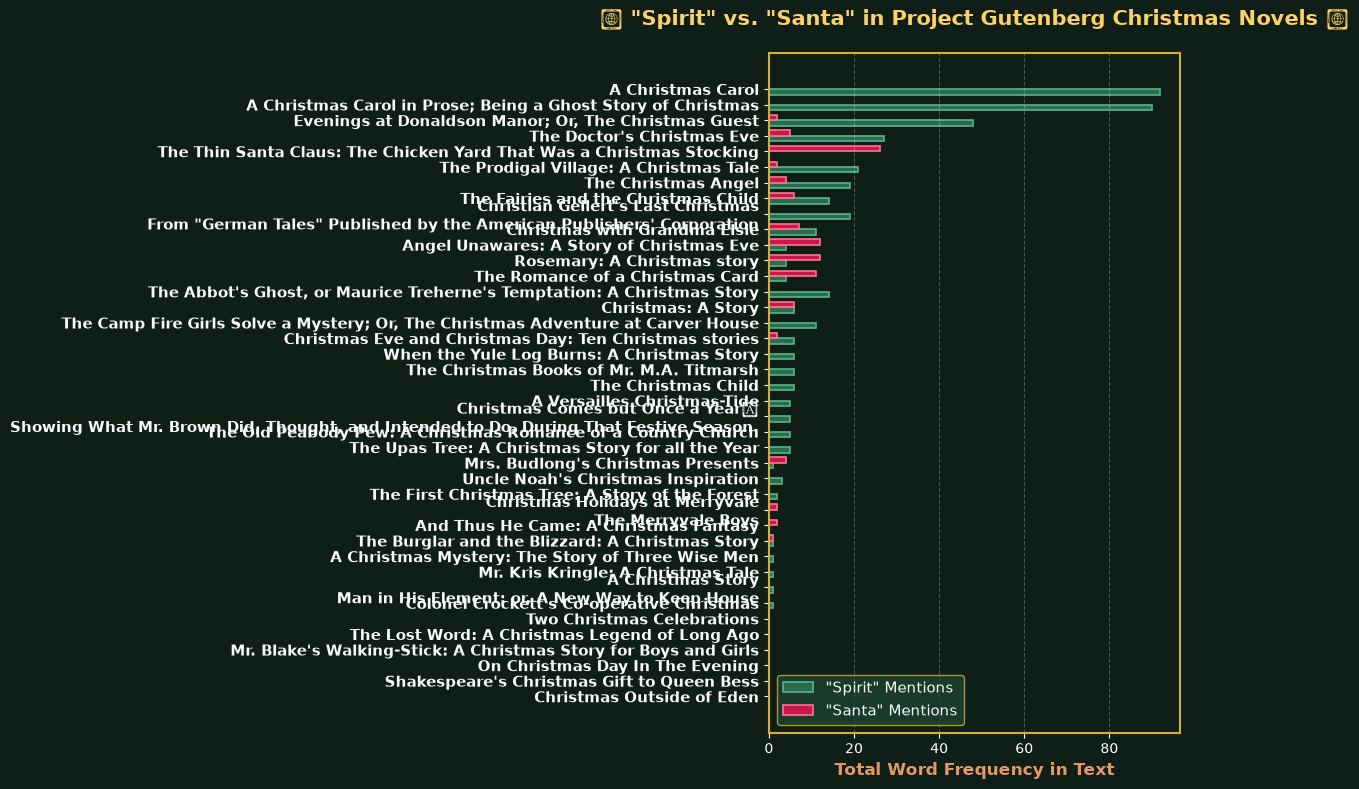

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print('Downloading TidyTuesday Christmas Novels dataset...')

# 1. Load Data Directly from GitHub
text_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-12-30/christmas_novel_text.csv'
novels_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-12-30/christmas_novels.csv'
authors_url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-12-30/christmas_novel_authors.csv'

df_text = pd.read_csv(text_url)
df_novels = pd.read_csv(novels_url)
df_authors = pd.read_csv(authors_url)

# 2. Merge Text with Novel Titles
df = pd.merge(df_text, df_novels, on='gutenberg_id', how='inner')
df['text'] = df['text'].fillna('')

print('Analyzing word frequencies ("spirit" vs "santa")...')

# 3. Count Case-Insensitive Mentions of "spirit" and "santa" per Novel
df['spirit_count'] = (
    df['text'].str.lower().str.findall(r'\bspirit\b').str.len()
)
df['santa_count'] = df['text'].str.lower().str.findall(r'\bsanta\b').str.len()

# Aggregate totals by novel title
novel_counts = (
    df.groupby('title')[['spirit_count', 'santa_count']]
    .sum()
    .reset_index()
)
novel_counts['total'] = (
    novel_counts['spirit_count'] + novel_counts['santa_count']
)
novel_counts = novel_counts.sort_values(by='total', ascending=True)

# 4. Create Christmas-Themed Visualization
print('Generating Christmas-themed chart...')

# Set festive dark-mode holiday aesthetic
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#0F1E17')
ax.set_facecolor('#0F1E17')

bar_width = 0.35
y = range(len(novel_counts))

# Festive Color Palette: Pine Green (#2D6A4F) & Crimson Red (#C9184A)
ax.barh(
    [i - bar_width / 2 for i in y],
    novel_counts['spirit_count'],
    height=bar_width,
    label='"Spirit" Mentions',
    color='#2D6A4F',
    edgecolor='#52B788',
    linewidth=1.2,
)
ax.barh(
    [i + bar_width / 2 for i in y],
    novel_counts['santa_count'],
    height=bar_width,
    label='"Santa" Mentions',
    color='#C9184A',
    edgecolor='#FF758F',
    linewidth=1.2,
)

# Typography & Formatting
ax.set_yticks(list(y))
ax.set_yticklabels(
    novel_counts['title'], fontsize=11, color='#F8F9FA', fontweight='bold'
)
ax.set_xlabel(
    'Total Word Frequency in Text',
    fontsize=12,
    color='#E59866',
    fontweight='bold',
)
ax.set_title(
    '🎄 "Spirit" vs. "Santa" in Project Gutenberg Christmas Novels 🎅',
    fontsize=15,
    color='#FFD166',
    pad=20,
    fontweight='bold',
)

# Legend & Grid styling
ax.legend(
    facecolor='#1B4332', edgecolor='#D4AF37', labelcolor='#F8F9FA', fontsize=11
)
ax.grid(axis='x', linestyle='--', alpha=0.25, color='#FFFFFF')

# Gold celebratory borders
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_color('#D4AF37')
    ax.spines[spine].set_linewidth(1.5)

plt.tight_layout()

# Save High-Resolution Image
output_filename = 'christmas_novels_spirit_vs_santa.png'
plt.savefig(output_filename, dpi=300, facecolor=fig.get_facecolor())
print(f"Success! Chart saved as '{output_filename}' 🎁")

plt.show()